
**Tecnologías:**
| Propósito | Librería |
|---|---|
| Procesado y estadística | `Pandas`, `NumPy` |
| Visualización | `Matplotlib`, `Seaborn` |
| Escalado | `Scikit-Learn (MinMaxScaler)` |
| Modelo | `Keras/TensorFlow (LSTM)` |
| Evaluación | `Scikit-Learn (RMSE, MAE, R²)` |
| Persistencia | `Joblib` |


## 1. Importaciones y configuración global

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Keras / TensorFlow ──────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Semilla de reproducibilidad ─────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Estilo global ────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

VENTANA = 10          # días de historia que ve el modelo
COLOR_REAL = '#2c7bb6'
COLOR_PRED = '#d7191c'
COLOR_VAL  = '#abdda4'

print("✅ Librerías cargadas | TF:", tf.__version__)

✅ Librerías cargadas | TF: 2.15.0


## 2. Carga de datos
Dataset **Online Retail** (UCI / Kaggle): transacciones de un e-commerce del Reino Unido.

In [ ]:
DATA_PATH = r'C:\Users\mrang\Desktop\Proyecto_ventas\data.csv'  

df_raw = pd.read_csv(DATA_PATH, encoding='latin1')
df = df_raw.copy()

print(f"Filas:    {df.shape[0]:>8,}")
print(f"Columnas: {df.shape[1]:>8}")
print(f"Periodo:  {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
df.head(8)

Filas:     541,909
Columnas:        8
Periodo:  1/10/2011 10:04 → 9/9/2011 9:52


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Visión general

In [29]:
print("── Tipos de dato ──────────────────────────────")
print(df.dtypes.to_string())
print()
print("── Valores nulos ──────────────────────────────")
nulos = df.isnull().sum()
print(nulos[nulos > 0].to_string())
print()
print("── Estadísticas descriptivas ──────────────────")
df.describe().round(2)

── Tipos de dato ──────────────────────────────
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str

── Valores nulos ──────────────────────────────
Description      1454
CustomerID     135080

── Estadísticas descriptivas ──────────────────


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


### 3.2 Mapa de valores nulos

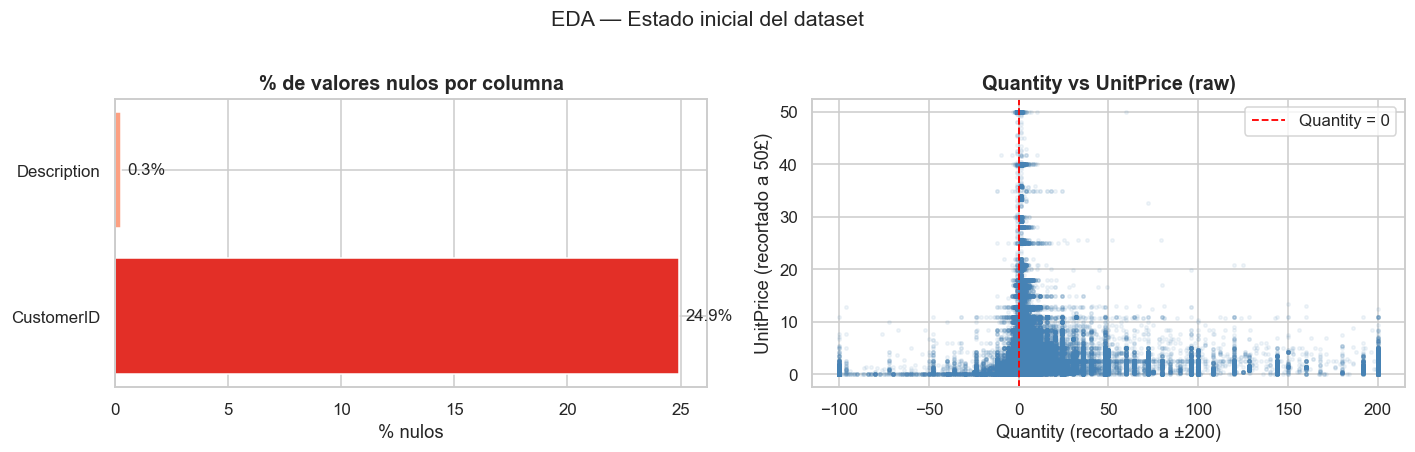

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barra de porcentaje
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
bars = axes[0].barh(null_pct.index, null_pct.values,
                    color=sns.color_palette('Reds_r', len(null_pct)))
axes[0].bar_label(bars, fmt='%.1f%%', padding=4)
axes[0].set_title('% de valores nulos por columna')
axes[0].set_xlabel('% nulos')

# Distribución de Quantity vs UnitPrice (antes de limpiar)
axes[1].scatter(df['Quantity'].clip(-100, 200),
                df['UnitPrice'].clip(0, 50),
                alpha=0.08, s=5, color='steelblue')
axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--', label='Quantity = 0')
axes[1].set_title('Quantity vs UnitPrice (raw)')
axes[1].set_xlabel('Quantity (recortado a ±200)')
axes[1].set_ylabel('UnitPrice (recortado a 50£)')
axes[1].legend()

plt.suptitle('EDA — Estado inicial del dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Transacciones con valores anómalos

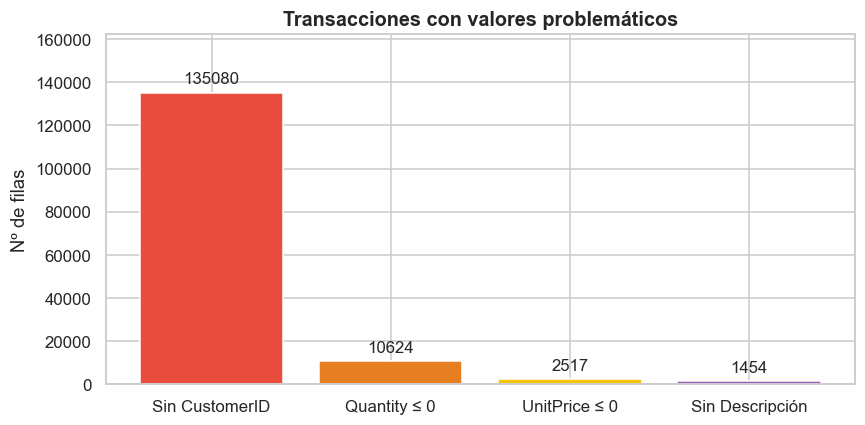

Total filas: 541,909  |  Problemáticas: 149,675 (27.6%)


In [31]:
n_sin_cliente = df['CustomerID'].isnull().sum()
n_qty_neg     = (df['Quantity'] <= 0).sum()
n_precio_neg  = (df['UnitPrice'] <= 0).sum()
n_sin_desc    = df['Description'].isnull().sum()

problemas = pd.Series({
    'Sin CustomerID': n_sin_cliente,
    'Quantity ≤ 0':    n_qty_neg,
    'UnitPrice ≤ 0':   n_precio_neg,
    'Sin Descripción': n_sin_desc
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(problemas.index, problemas.values,
              color=['#e74c3c','#e67e22','#f1c40f','#9b59b6'], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
ax.set_title('Transacciones con valores problemáticos')
ax.set_ylabel('Nº de filas')
ax.set_ylim(0, problemas.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"Total filas: {len(df):,}  |  Problemáticas: {problemas.sum():,} "
      f"({problemas.sum()/len(df)*100:.1f}%)")

### 3.4 Distribución de ventas brutas por país

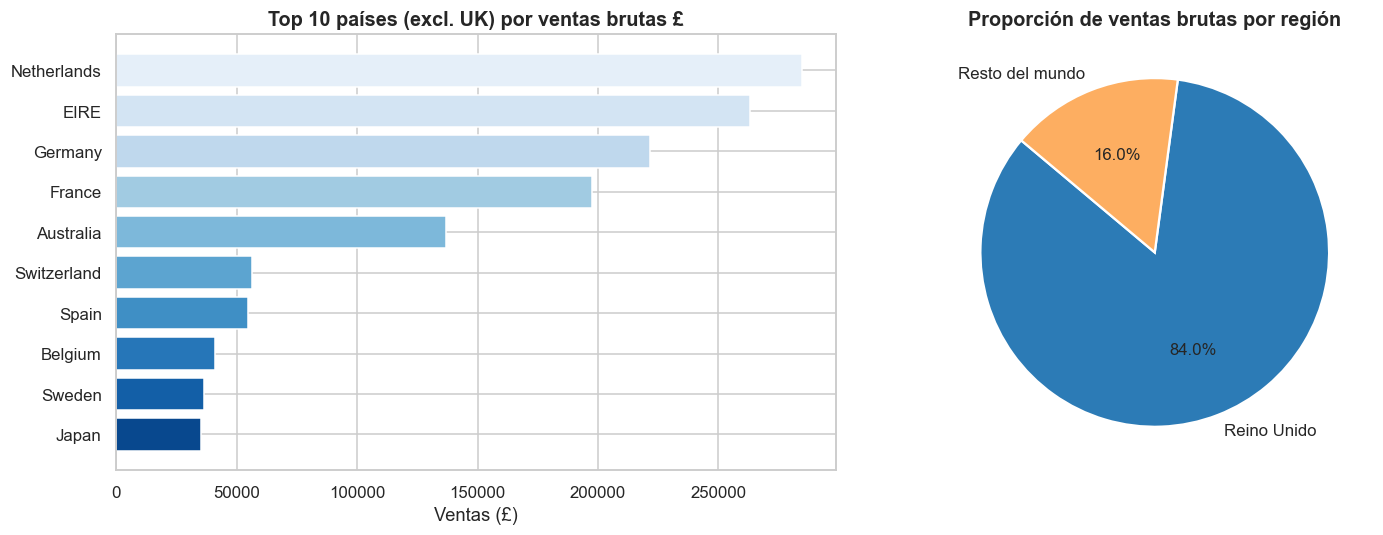

In [32]:
# Ventas brutas (antes de limpiar)
df['TotalBruto'] = df['Quantity'] * df['UnitPrice']
paises = (df[df['Country'] != 'United Kingdom']
          .groupby('Country')['TotalBruto']
          .sum()
          .sort_values(ascending=False)
          .head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot top países (excl. UK)
axes[0].barh(paises.index[::-1], paises.values[::-1],
             color=sns.color_palette('Blues_r', 10))
axes[0].set_title('Top 10 países (excl. UK) por ventas brutas £')
axes[0].set_xlabel('Ventas (£)')

# Pie: UK vs Resto
uk_total = df[df['Country'] == 'United Kingdom']['TotalBruto'].sum()
resto    = df[df['Country'] != 'United Kingdom']['TotalBruto'].sum()
axes[1].pie([uk_total, resto],
            labels=['Reino Unido', 'Resto del mundo'],
            autopct='%1.1f%%',
            colors=['#2c7bb6', '#fdae61'],
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción de ventas brutas por región')

plt.tight_layout()
plt.show()

### 3.5 Distribución de UnitPrice y Quantity

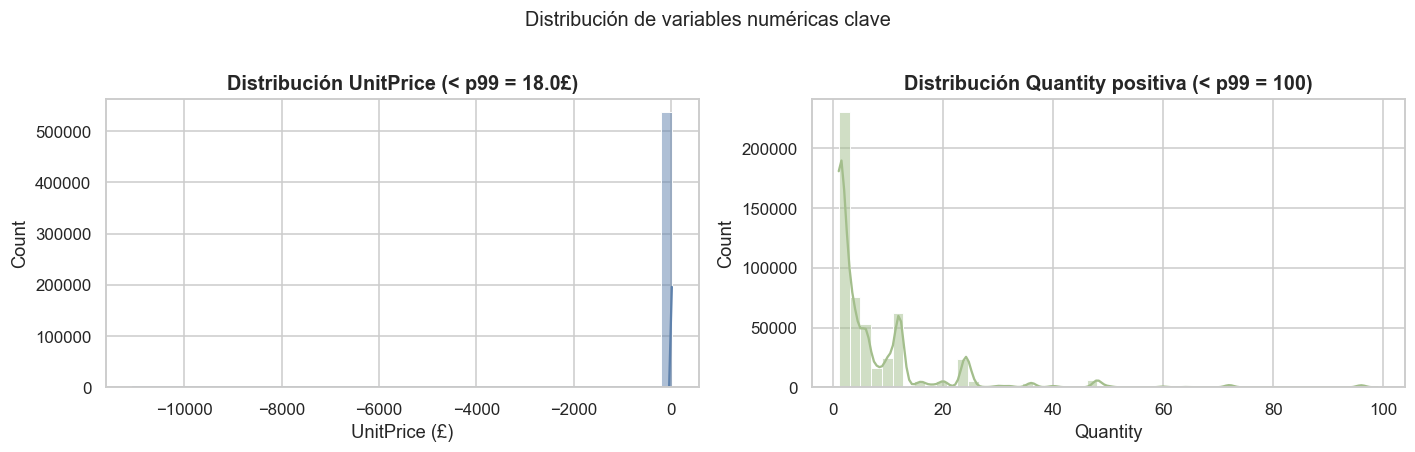

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# UnitPrice (recortado en percentil 99)
p99_precio = df['UnitPrice'].quantile(0.99)
sns.histplot(df[df['UnitPrice'] < p99_precio]['UnitPrice'],
             bins=50, ax=axes[0], color='#5e81ac', kde=True)
axes[0].set_title(f'Distribución UnitPrice (< p99 = {p99_precio:.1f}£)')
axes[0].set_xlabel('UnitPrice (£)')

# Quantity positiva (recortada)
p99_qty = df[df['Quantity'] > 0]['Quantity'].quantile(0.99)
sns.histplot(df[(df['Quantity'] > 0) & (df['Quantity'] < p99_qty)]['Quantity'],
             bins=50, ax=axes[1], color='#a3be8c', kde=True)
axes[1].set_title(f'Distribución Quantity positiva (< p99 = {p99_qty:.0f})')
axes[1].set_xlabel('Quantity')

plt.suptitle('Distribución de variables numéricas clave', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Limpieza de datos

In [34]:
df_clean = df_raw.copy()

# ── Fecha a datetime ────────────────────────────────────────
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Eliminar filas sin descripción ──────────────────────────
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Sin descripción eliminadas:  {antes - len(df_clean):>6,}")

# ── Eliminar quantity ≤ 0 (devoluciones/regalos) ────────────
antes = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"Quantity ≤ 0 eliminadas:     {antes - len(df_clean):>6,}")

# ── Eliminar precio ≤ 0 ─────────────────────────────────────
antes = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"UnitPrice ≤ 0 eliminadas:    {antes - len(df_clean):>6,}")

# ── Outliers de UnitPrice (> p99.5) ─────────────────────────
umbral_precio = df_clean['UnitPrice'].quantile(0.995)
antes = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] <= umbral_precio]
print(f"Outliers UnitPrice eliminados:{antes - len(df_clean):>5,}  (umbral {umbral_precio:.2f}£)")

# ── Outliers de Quantity (> p99.5) ──────────────────────────
umbral_qty = df_clean['Quantity'].quantile(0.995)
antes = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] <= umbral_qty]
print(f"Outliers Quantity eliminados: {antes - len(df_clean):>5,}  (umbral {umbral_qty:.0f})")

print(f"\n✅ Filas finales: {len(df_clean):,}  "
      f"({len(df_clean)/len(df_raw)*100:.1f}% del original)")

Sin descripción eliminadas:   1,454
Quantity ≤ 0 eliminadas:      9,762
UnitPrice ≤ 0 eliminadas:       589
Outliers UnitPrice eliminados:2,255  (umbral 24.96£)
Outliers Quantity eliminados: 2,613  (umbral 160)

✅ Filas finales: 525,236  (96.9% del original)


### 4.1 Comparativa antes/después de la limpieza — Boxplots

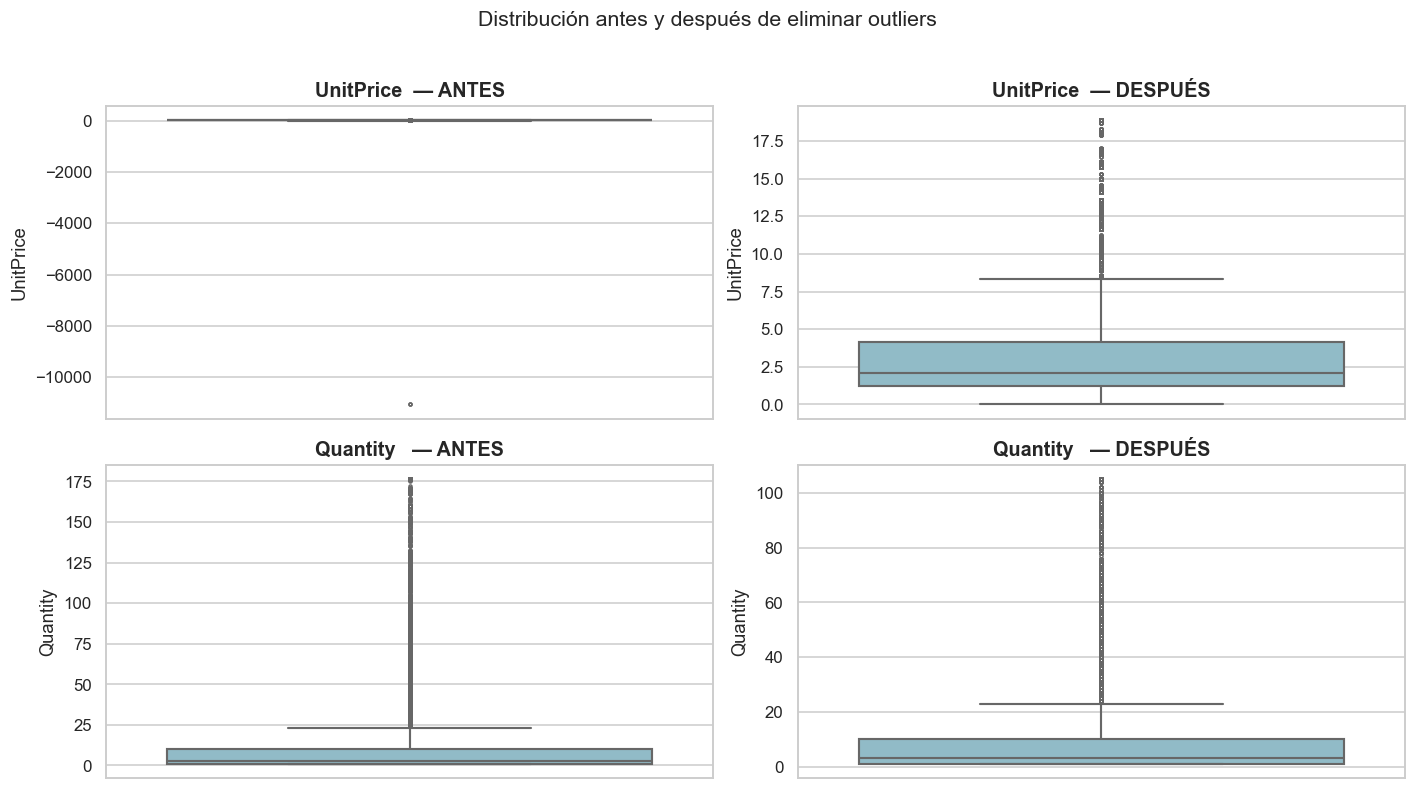

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, data, col, titulo in [
    (axes[0,0], df_raw,   'UnitPrice', 'UnitPrice  — ANTES'),
    (axes[0,1], df_clean, 'UnitPrice', 'UnitPrice  — DESPUÉS'),
    (axes[1,0], df_raw[df_raw['Quantity']>0], 'Quantity', 'Quantity   — ANTES'),
    (axes[1,1], df_clean, 'Quantity', 'Quantity   — DESPUÉS'),
]:
    clip_val = data[col].quantile(0.995) * 1.05
    sns.boxplot(y=data[col].clip(upper=clip_val), ax=ax,
                color='#88c0d0', linewidth=1.4, flierprops={'markersize': 2})
    ax.set_title(titulo)
    ax.set_ylabel(col)

plt.suptitle('Distribución antes y después de eliminar outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Ingeniería de características y agregación diaria

In [36]:
# ── Ventas totales por transacción ──────────────────────────
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# ── Agregar por día ─────────────────────────────────────────
df_daily = (df_clean
            .groupby(df_clean['InvoiceDate'].dt.date)
            .agg(
                TotalSales    = ('TotalSales', 'sum'),
                NumTransac    = ('InvoiceNo', 'nunique'),
                NumProductos  = ('StockCode', 'nunique'),
                NumClientes   = ('CustomerID', 'nunique'),
                TicketMedio   = ('TotalSales', 'mean'),
            )
            .reset_index()
            .rename(columns={'InvoiceDate': 'Date'}))

df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily = df_daily.sort_values('Date').reset_index(drop=True)

# ── Variables de calendario ──────────────────────────────────
df_daily['DayOfWeek']   = df_daily['Date'].dt.dayofweek      # 0=lun
df_daily['WeekOfMonth'] = (df_daily['Date'].dt.day - 1) // 7 + 1
df_daily['Month']       = df_daily['Date'].dt.month
df_daily['IsMonday']    = (df_daily['DayOfWeek'] == 0).astype(int)
df_daily['IsWeekend']   = (df_daily['DayOfWeek'] >= 5).astype(int)

# ── Lag features (días anteriores) ──────────────────────────
for lag in [1, 7, 14]:
    df_daily[f'Lag_{lag}'] = df_daily['TotalSales'].shift(lag)

# ── Media móvil 7 días ───────────────────────────────────────
df_daily['RollingMean7'] = (df_daily['TotalSales']
                             .shift(1).rolling(7).mean())

df_daily = df_daily.dropna().reset_index(drop=True)

print(f"Días totales disponibles: {len(df_daily)}")
print(f"Rango: {df_daily['Date'].min().date()} → {df_daily['Date'].max().date()}")
df_daily.head(8)

Días totales disponibles: 291
Rango: 2010-12-17 → 2011-12-09


,Date,TotalSales,NumTransac,NumProductos,NumClientes,TicketMedio,DayOfWeek,WeekOfMonth,Month,IsMonday,IsWeekend,Lag_1,Lag_7,Lag_14,RollingMean7
0,2010-12-17,38364.34,63,1348,49,12.594990,4,3,12,0,0,37260.57,44328.74,49791.92,35907.362857
1,2010-12-19,7484.91,23,389,17,14.477582,6,3,12,0,1,38364.34,51145.24,41731.68,35055.305714
2,2010-12-20,23603.14,60,913,40,14.330990,0,3,12,1,0,7484.91,17035.31,42238.86,28818.115714
3,2010-12-21,31167.69,53,796,22,20.861908,1,3,12,0,0,23603.14,34459.03,30620.71,29756.377143
4,2010-12-22,4401.57,15,191,12,20.007136,2,4,12,0,0,31167.69,40472.99,48035.83,29286.185714
5,2010-12-23,11088.42,27,780,15,11.846603,3,4,12,0,0,4401.57,26649.66,51994.31,24133.125714
6,2011-01-04,15192.41,36,815,34,13.222289,1,1,1,0,0,11088.42,37260.57,41053.95,21910.091429
7,2011-01-05,26664.67,53,985,43,16.189842,2,1,1,0,0,15192.41,38364.34,44328.74,18757.497143


### 5.1 Evolución de ventas diarias

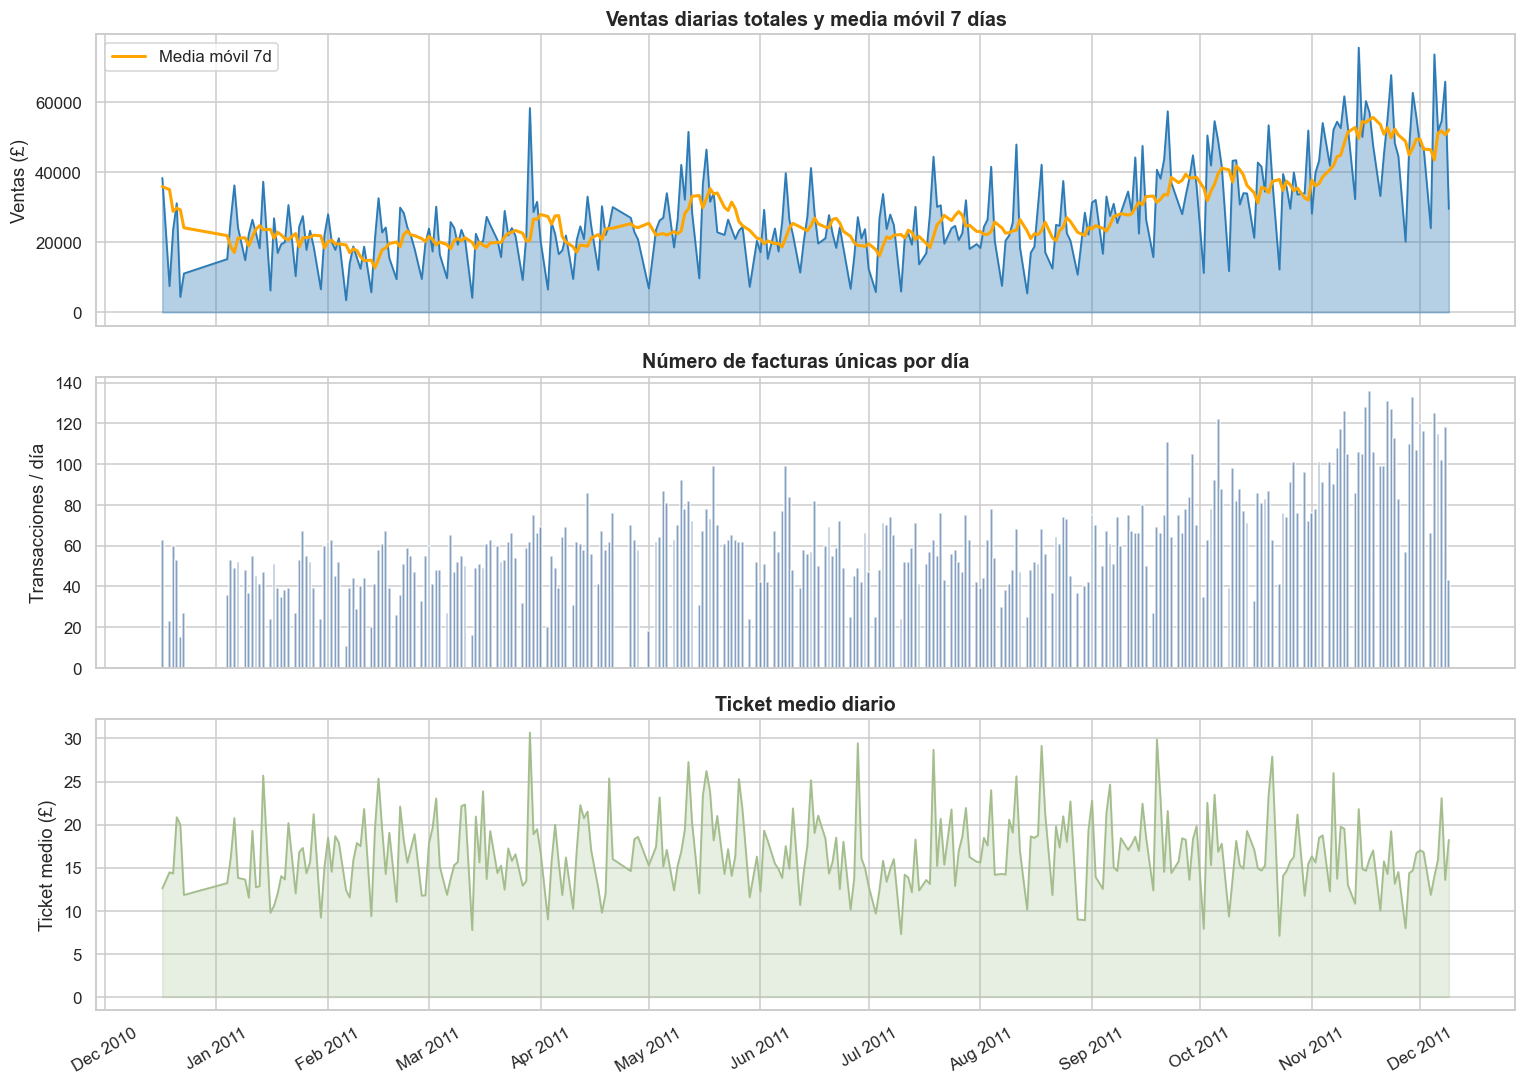

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Ventas totales
axes[0].fill_between(df_daily['Date'], df_daily['TotalSales'],
                     alpha=0.35, color=COLOR_REAL)
axes[0].plot(df_daily['Date'], df_daily['TotalSales'],
             color=COLOR_REAL, linewidth=1.2)
axes[0].plot(df_daily['Date'], df_daily['RollingMean7'],
             color='orange', linewidth=2, label='Media móvil 7d')
axes[0].set_ylabel('Ventas (£)')
axes[0].set_title('Ventas diarias totales y media móvil 7 días')
axes[0].legend()

# Número de transacciones
axes[1].bar(df_daily['Date'], df_daily['NumTransac'],
            width=0.8, color='#5e81ac', alpha=0.75)
axes[1].set_ylabel('Transacciones / día')
axes[1].set_title('Número de facturas únicas por día')

# Ticket medio
axes[2].plot(df_daily['Date'], df_daily['TicketMedio'],
             color='#a3be8c', linewidth=1.2)
axes[2].fill_between(df_daily['Date'], df_daily['TicketMedio'],
                     alpha=0.25, color='#a3be8c')
axes[2].set_ylabel('Ticket medio (£)')
axes[2].set_title('Ticket medio diario')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

### 5.2 Análisis por día de la semana y mes

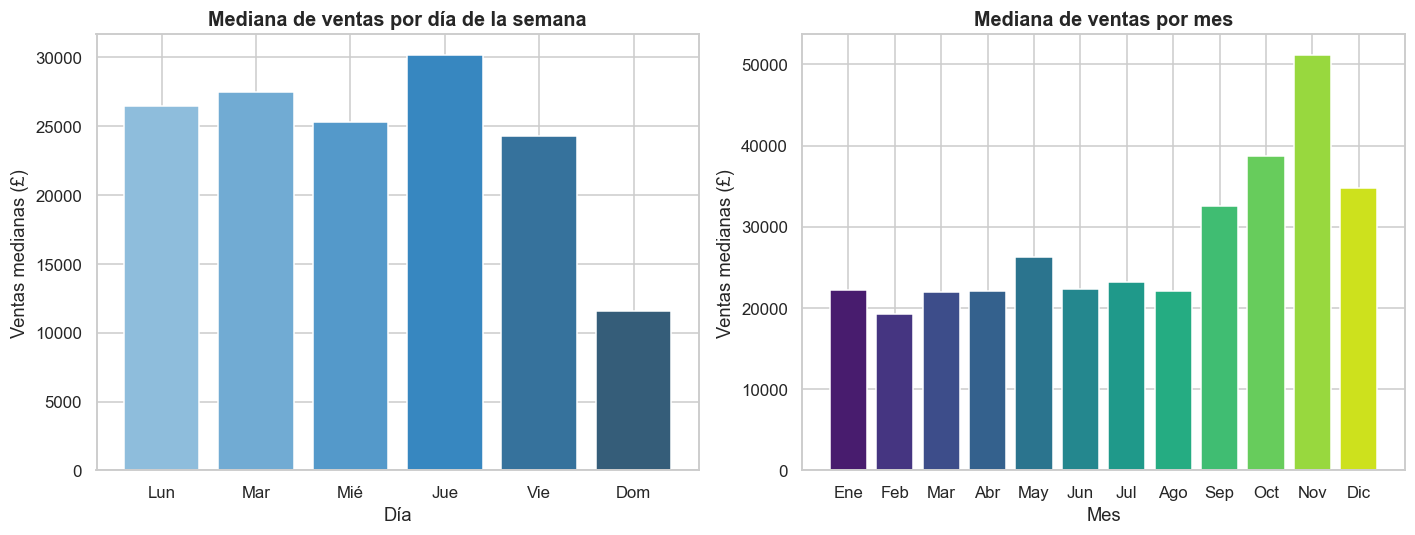

In [38]:
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
meses = ['Ene','Feb','Mar','Abr','May','Jun',
          'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ventas por día de la semana
ventas_dow = df_daily.groupby('DayOfWeek')['TotalSales'].median()
axes[0].bar([dias[i] for i in ventas_dow.index], ventas_dow.values,
            color=sns.color_palette('Blues_d', 7), edgecolor='white')
axes[0].set_title('Mediana de ventas por día de la semana')
axes[0].set_ylabel('Ventas medianas (£)')
axes[0].set_xlabel('Día')

# Ventas por mes
ventas_mes = df_daily.groupby('Month')['TotalSales'].median()
colores_mes = sns.color_palette('viridis', 12)
axes[1].bar([meses[m-1] for m in ventas_mes.index], ventas_mes.values,
            color=colores_mes, edgecolor='white')
axes[1].set_title('Mediana de ventas por mes')
axes[1].set_ylabel('Ventas medianas (£)')
axes[1].set_xlabel('Mes')

plt.tight_layout()
plt.show()

### 5.3 Mapa de calor de correlaciones

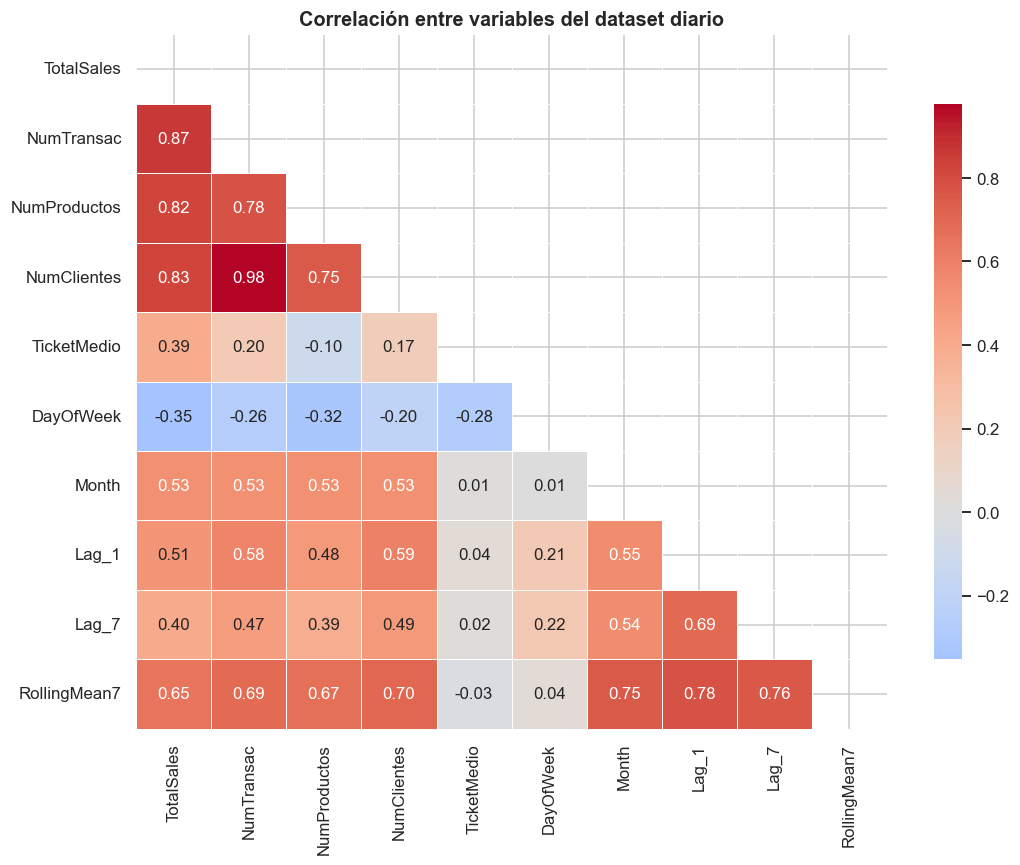

In [39]:
num_cols = ['TotalSales','NumTransac','NumProductos','NumClientes',
            'TicketMedio','DayOfWeek','Month','Lag_1','Lag_7','RollingMean7']

corr = df_daily[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre variables del dataset diario')
plt.tight_layout()
plt.show()

### 5.4 Relaciones entre variables clave

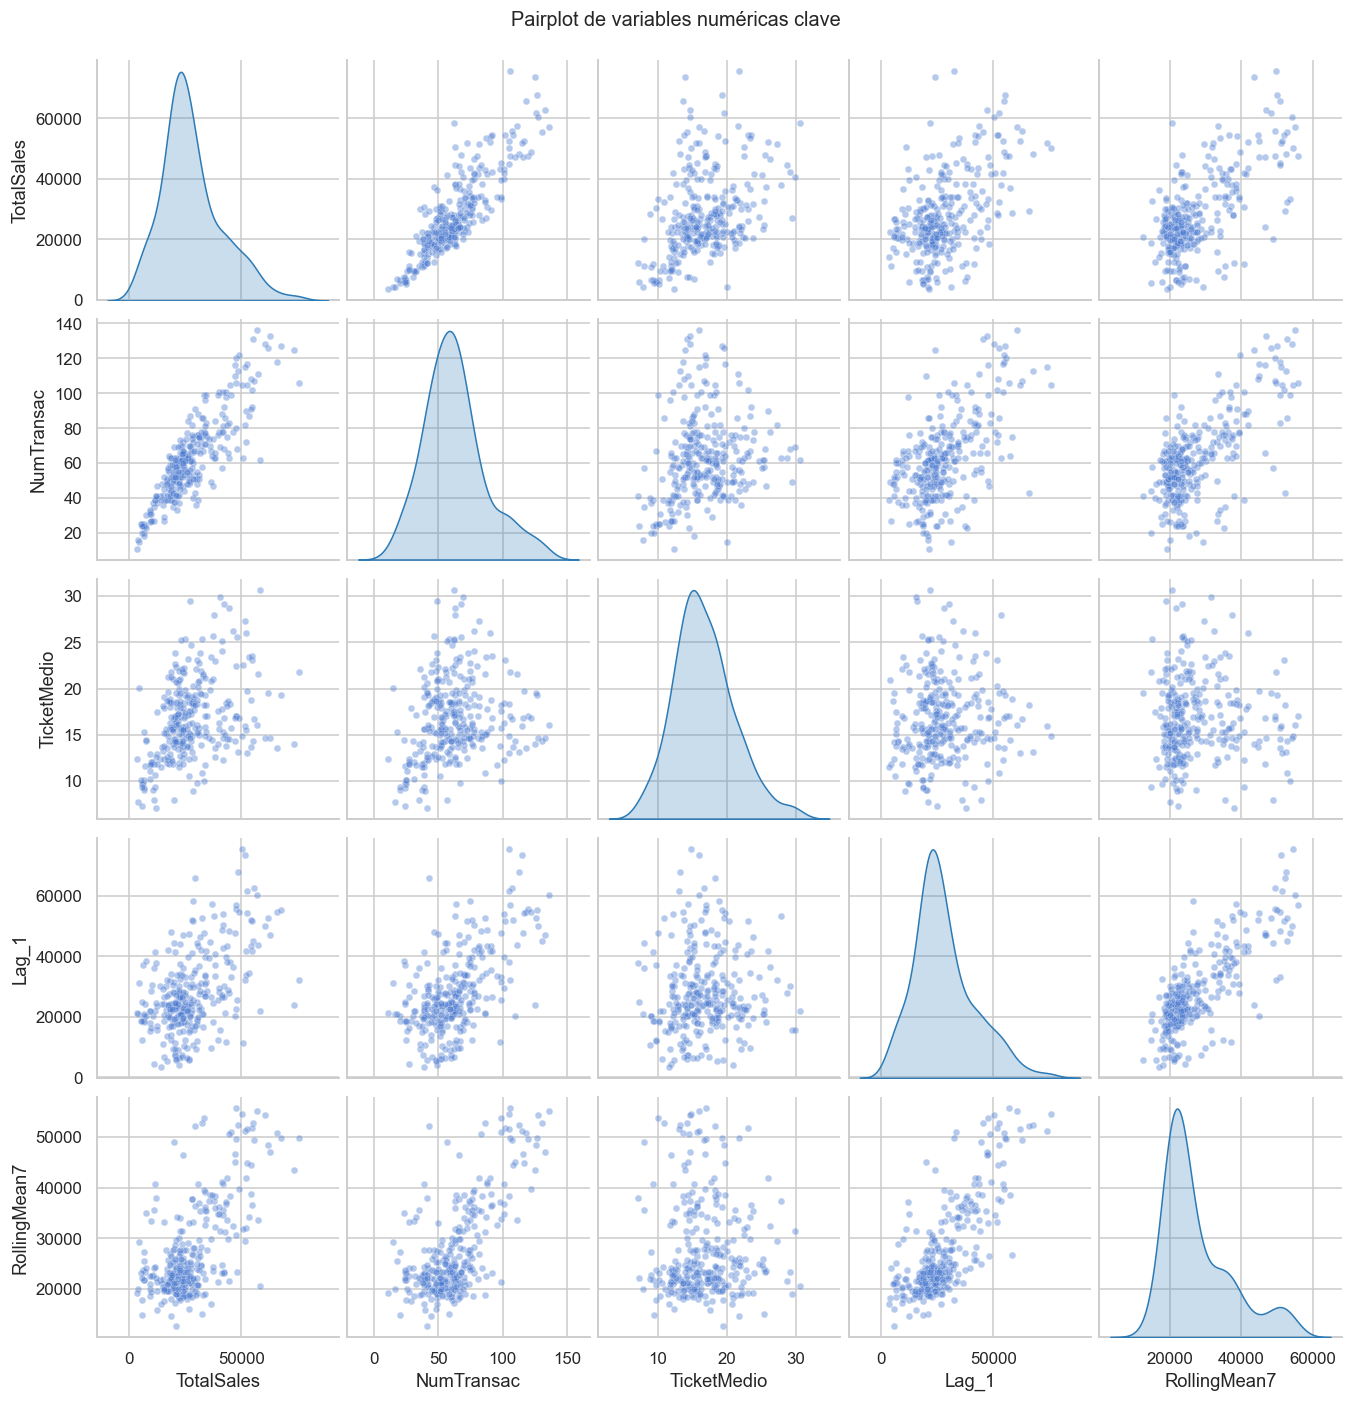

In [40]:
pair_cols = ['TotalSales','NumTransac','TicketMedio','Lag_1','RollingMean7']

g = sns.pairplot(df_daily[pair_cols].sample(min(300, len(df_daily)), random_state=SEED),
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20},
                 diag_kws={'color': COLOR_REAL})
g.figure.suptitle('Pairplot de variables numéricas clave', y=1.02, fontsize=13)
plt.show()

### 5.5 Distribución de ventas por mes (Boxplot)

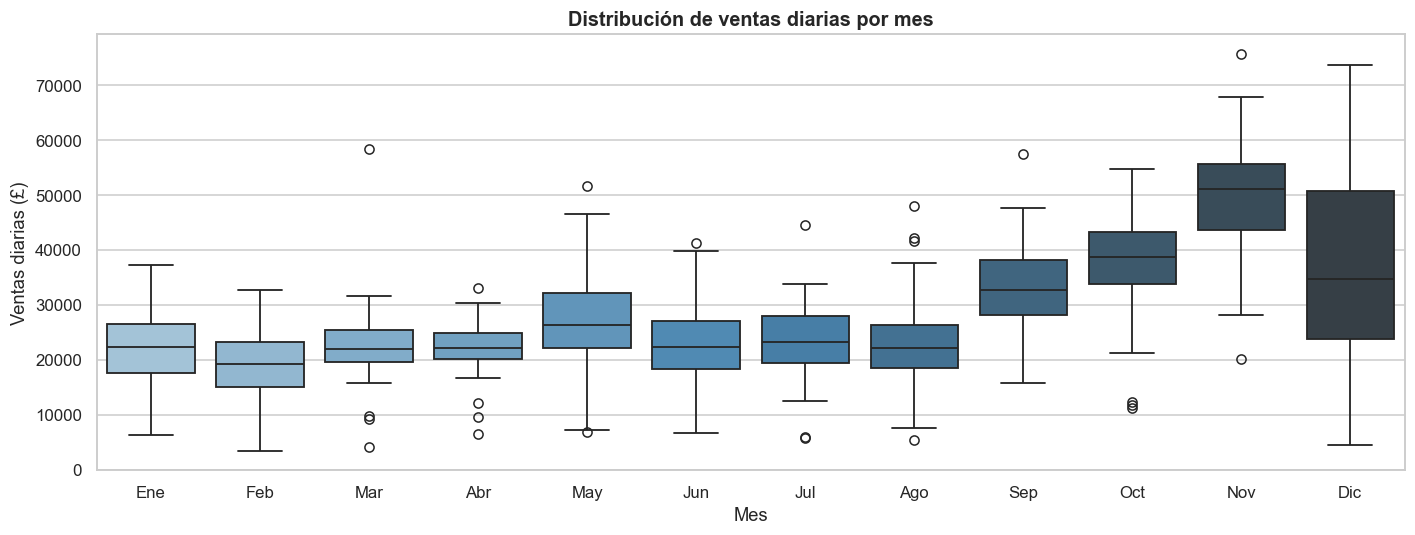

In [41]:
fig, ax = plt.subplots(figsize=(13, 5))
meses_labels = {i+1: m for i, m in enumerate(
    ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])}
df_daily['MesLabel'] = df_daily['Month'].map(meses_labels)

order = [meses_labels[m] for m in sorted(df_daily['Month'].unique())]
sns.boxplot(data=df_daily, x='MesLabel', y='TotalSales', order=order,
            palette='Blues_d', ax=ax, linewidth=1.2)
ax.set_title('Distribución de ventas diarias por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas diarias (£)')
plt.tight_layout()
plt.show()

## 6. División temporal Train / Validación / Test

| Split | Rango | Uso |
|---|---|---|
| **Train** | 01-dic-2010 → 08-oct-2011 | Entrenamiento del modelo |
| **Val** | 09-oct-2011 → 08-nov-2011 | Ajuste de hiperparámetros |
| **Test** | 09-nov-2011 → 09-dic-2011 | Evaluación final |

Train: 237 días  2010-12-17 → 2011-10-07
Val:    27 días  2011-10-09 → 2011-11-08
Test:   27 días  2011-11-09 → 2011-12-09


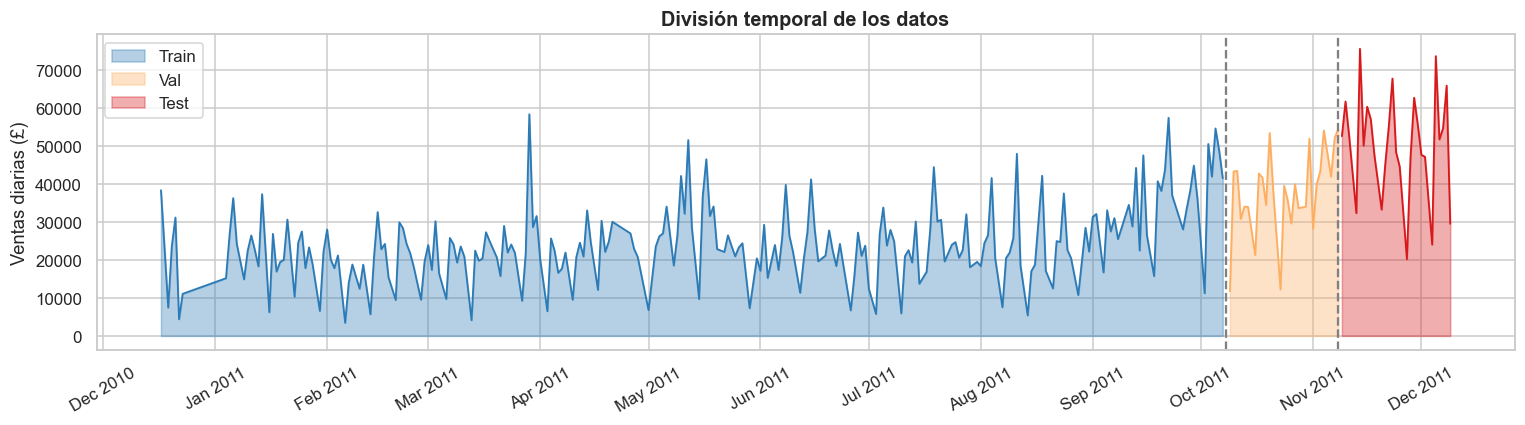

In [42]:
TRAIN_END = '2011-10-08'
VAL_END   = '2011-11-08'

train = df_daily[df_daily['Date'] <= TRAIN_END].copy()
val   = df_daily[(df_daily['Date'] > TRAIN_END) & (df_daily['Date'] <= VAL_END)].copy()
test  = df_daily[df_daily['Date'] > VAL_END].copy()

print(f"Train: {len(train):>3} días  {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Val:   {len(val):>3} días  {val['Date'].min().date()   } → {val['Date'].max().date()}")
print(f"Test:  {len(test):>3} días  {test['Date'].min().date() } → {test['Date'].max().date()}")

# Visualización de la división
fig, ax = plt.subplots(figsize=(14, 4))
for split, color, label in [
    (train, '#2c7bb6', 'Train'),
    (val,   '#fdae61', 'Val'),
    (test,  '#d7191c', 'Test'),
]:
    ax.fill_between(split['Date'], split['TotalSales'],
                    alpha=0.35, color=color, label=label)
    ax.plot(split['Date'], split['TotalSales'], color=color, linewidth=1.2)

ax.axvline(pd.to_datetime(TRAIN_END), color='gray', linestyle='--', linewidth=1.5)
ax.axvline(pd.to_datetime(VAL_END),   color='gray', linestyle='--', linewidth=1.5)
ax.set_title('División temporal de los datos')
ax.set_ylabel('Ventas diarias (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Escalado MinMax de las ventas

Rango tras escalar (train):
  min = 0.0000  |  max = 1.0000


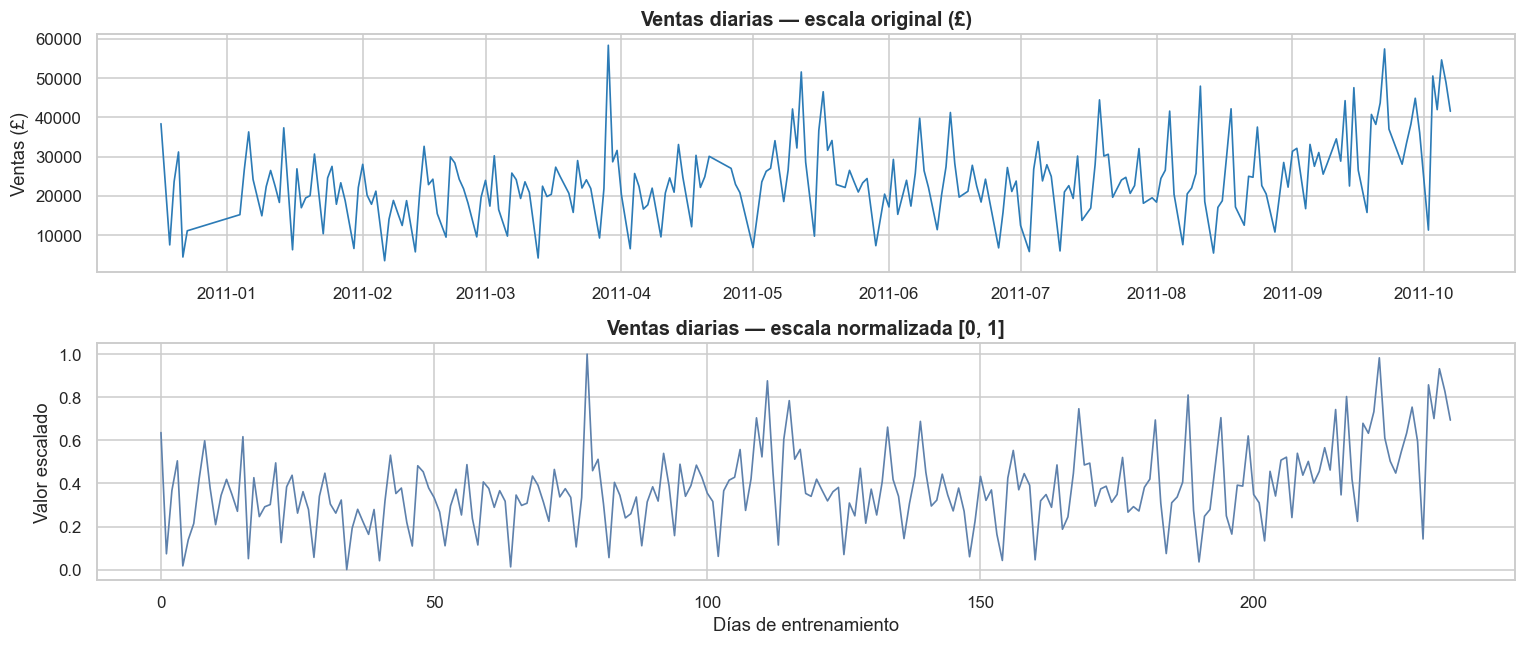

In [43]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train[['TotalSales']])
val_scaled   = scaler.transform(val[['TotalSales']])
test_scaled  = scaler.transform(test[['TotalSales']])

print("Rango tras escalar (train):")
print(f"  min = {train_scaled.min():.4f}  |  max = {train_scaled.max():.4f}")

# Visualización: serie original vs escalada
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(train['Date'], train['TotalSales'], color=COLOR_REAL, linewidth=1.1)
axes[0].set_title('Ventas diarias — escala original (£)')
axes[0].set_ylabel('Ventas (£)')

axes[1].plot(range(len(train_scaled)), train_scaled, color='#5e81ac', linewidth=1.1)
axes[1].set_title('Ventas diarias — escala normalizada [0, 1]')
axes[1].set_ylabel('Valor escalado')
axes[1].set_xlabel('Días de entrenamiento')

plt.tight_layout()
plt.show()

## 8. Construcción de secuencias para LSTM
El modelo recibe una ventana de **10 días** consecutivos como entrada y predice el día siguiente.

In [44]:
def crear_secuencias(data, ventana=VENTANA):
    """Convierte una serie 1D en pares (X_window, y_next)."""
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i : i + ventana])
        y.append(data[i + ventana])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias(train_scaled, VENTANA)
X_val,   y_val   = crear_secuencias(val_scaled,   VENTANA)
X_test,  y_test  = crear_secuencias(test_scaled,  VENTANA)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    |  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")

X_train: (227, 10, 1)  |  y_train: (227, 1)
X_val:   (17, 10, 1)    |  y_val:   (17, 1)
X_test:  (17, 10, 1)   |  y_test:  (17, 1)


## 9. Arquitectura LSTM
Se usa una red **Bidirectional LSTM** de dos capas con Dropout y un callback `ReduceLROnPlateau` para ajustar el learning rate cuando el val_loss se estanca.

In [45]:
model = Sequential([
    Bidirectional(LSTM(128, activation='tanh', return_sequences=True),
                  input_shape=(VENTANA, 1)),
    Dropout(0.25),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dense(1)
], name='LSTM_Ventas')

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model.summary()
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train: {len(train)} días")
print(f"Val:   {len(val)} días")
print(f"Test:  {len(test)} días")
print(f"Ventana: {VENTANA}")
print(f"Secuencias posibles en val:  {len(val) - VENTANA}")
print(f"Secuencias posibles en test: {len(test) - VENTANA}")

Model: "LSTM_Ventas"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirecti  (None, 10, 256)           133120    
 onal)                                                           
                                                                 
 dropout_6 (Dropout)         (None, 10, 256)           0         
                                                                 
 lstm_7 (LSTM)               (None, 64)                82176     
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 1)                 33        
                                                       

### 9.1 Entrenamiento

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

mejor_epoca = int(np.argmin(history.history['val_loss'])) + 1
mejor_val   = min(history.history['val_loss'])
print(f"\n✅ Mejor época: {mejor_epoca}  |  val_loss mínimo: {mejor_val:.6f}")

Epoch 1/150
15/15 [==============================] - 3s 48ms/step - loss: 0.0633 - val_loss: 0.1204 - lr: 0.0010
Epoch 2/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0378 - val_loss: 0.0390 - lr: 0.0010
Epoch 3/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0333 - val_loss: 0.0564 - lr: 0.0010
Epoch 4/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0318 - val_loss: 0.0758 - lr: 0.0010
Epoch 5/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0335 - val_loss: 0.0411 - lr: 0.0010
Epoch 6/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0340 - val_loss: 0.0815 - lr: 0.0010
Epoch 7/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0333 - val_loss: 0.0708 - lr: 0.0010
Epoch 8/150
15/15 [==============================] - 0s 5ms/step - loss: 0.0306 - val_loss: 0.0628 - lr: 0.0010
Epoch 9/150
14/15 [===========================>..] - ETA: 0s - loss: 0.0308
Epoch 9: ReduceLROnPlateau 

### 9.2 Curvas de pérdida (Train vs Val)

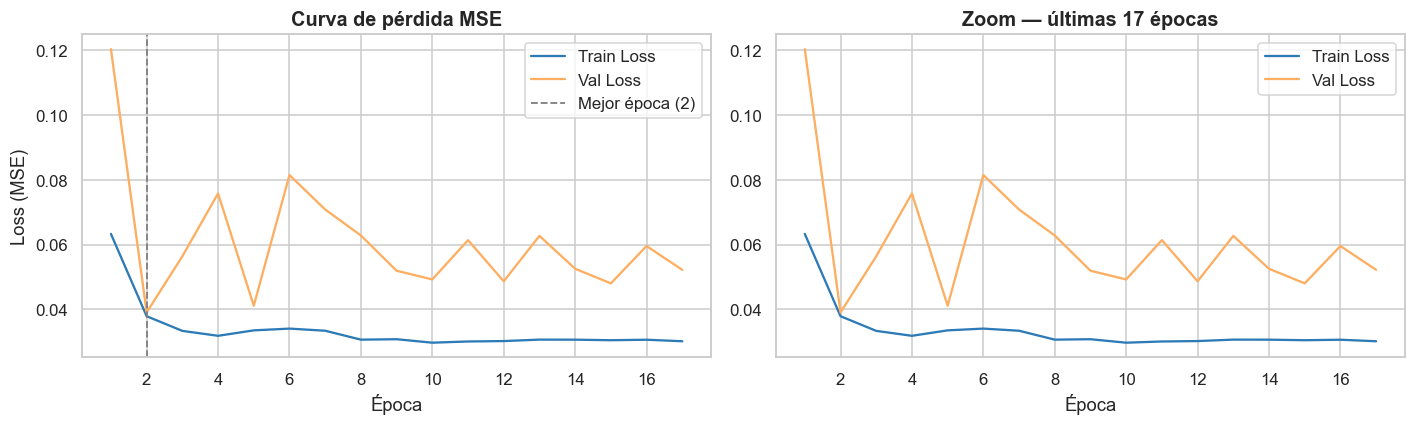

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history.history['loss']) + 1)

# Pérdida completa
axes[0].plot(epochs_range, history.history['loss'],
             label='Train Loss', color=COLOR_REAL, linewidth=1.5)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val Loss',   color='#fdae61', linewidth=1.5)
axes[0].axvline(mejor_epoca, color='gray', linestyle='--', linewidth=1.2,
                label=f'Mejor época ({mejor_epoca})')
axes[0].set_title('Curva de pérdida MSE')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

# Zoom: últimas épocas útiles
n_show = min(60, len(history.history['loss']))
axes[1].plot(list(epochs_range)[-n_show:], history.history['loss'][-n_show:],
             color=COLOR_REAL, linewidth=1.5, label='Train Loss')
axes[1].plot(list(epochs_range)[-n_show:], history.history['val_loss'][-n_show:],
             color='#fdae61', linewidth=1.5, label='Val Loss')
axes[1].set_title(f'Zoom — últimas {n_show} épocas')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Predicción y evaluación sobre el conjunto de Test

In [48]:
# Predicciones escaladas → escala real
y_pred_scaled = model.predict(X_test)
y_pred_real   = scaler.inverse_transform(y_pred_scaled)
y_test_real   = scaler.inverse_transform(y_test)

# ── Métricas ────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-9))) * 100

print("══════════════════════════════════════")
print("    MÉTRICAS FINALES — Test Set")
print("══════════════════════════════════════")
print(f"  RMSE : £{rmse:>10,.2f}")
print(f"  MAE  : £{mae:>10,.2f}")
print(f"  MAPE :  {mape:>9.2f} %")
print(f"  R²   :  {r2:>9.4f}")
print("══════════════════════════════════════")

1/1 [==============================] - 1s 512ms/step
══════════════════════════════════════
    MÉTRICAS FINALES — Test Set
══════════════════════════════════════
  RMSE : £ 15,234.11
  MAE  : £ 11,873.23
  MAPE :      30.07 %
  R²   :    -0.1510
══════════════════════════════════════


### 10.1 Predicciones vs Ventas reales

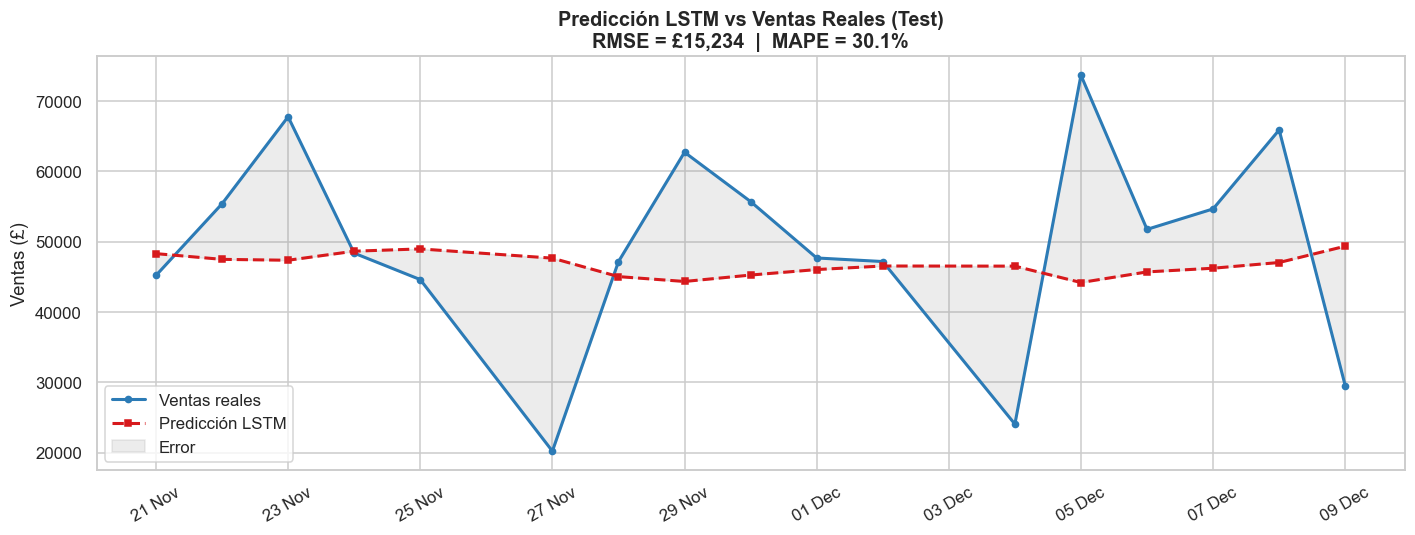

In [49]:
# Fechas del test (ajustadas al tamaño de secuencia)
fechas_test = test['Date'].values[VENTANA:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_test, y_test_real,
        label='Ventas reales', color=COLOR_REAL, linewidth=2, marker='o', markersize=4)
ax.plot(fechas_test, y_pred_real,
        label='Predicción LSTM', color=COLOR_PRED,
        linewidth=2, linestyle='--', marker='s', markersize=4)
ax.fill_between(fechas_test,
                y_test_real.flatten(), y_pred_real.flatten(),
                alpha=0.15, color='gray', label='Error')
ax.set_title(f'Predicción LSTM vs Ventas Reales (Test)\nRMSE = £{rmse:,.0f}  |  MAPE = {mape:.1f}%')
ax.set_ylabel('Ventas (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 10.2 Análisis de residuos

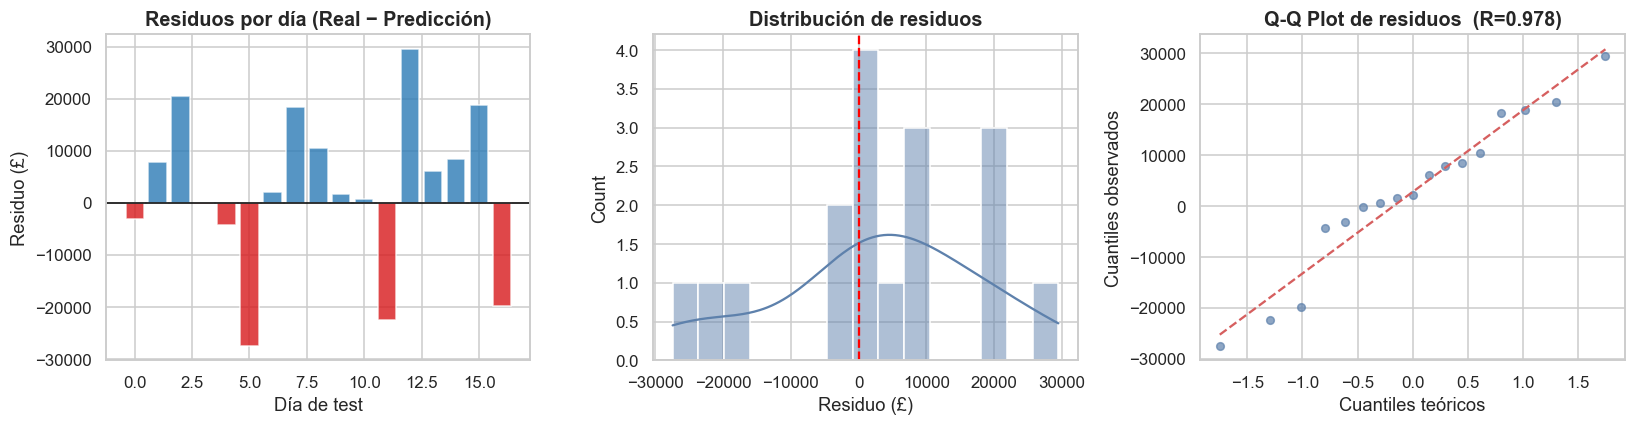

In [50]:
residuos = y_test_real.flatten() - y_pred_real.flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuos en el tiempo
axes[0].bar(range(len(residuos)), residuos,
            color=[COLOR_PRED if r < 0 else COLOR_REAL for r in residuos],
            alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuos por día (Real − Predicción)')
axes[0].set_xlabel('Día de test')
axes[0].set_ylabel('Residuo (£)')

# Histograma de residuos
sns.histplot(residuos, bins=15, kde=True, ax=axes[1],
             color='#5e81ac', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo (£)')

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[2].plot(osm, osr, 'o', color='#5e81ac', markersize=5, alpha=0.7)
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[2].set_title(f'Q-Q Plot de residuos  (R={r:.3f})')
axes[2].set_xlabel('Cuantiles teóricos')
axes[2].set_ylabel('Cuantiles observados')

plt.tight_layout()
plt.show()

### 10.3 Scatter: Real vs Predicho

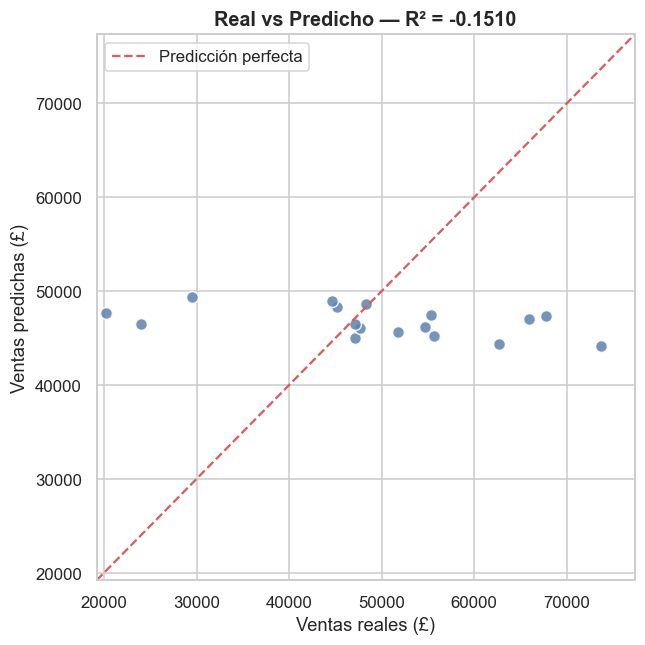

In [51]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_real, y_pred_real, color='#5e81ac', edgecolor='white',
           s=60, alpha=0.85)
lim = [min(y_test_real.min(), y_pred_real.min()) * 0.95,
       max(y_test_real.max(), y_pred_real.max()) * 1.05]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title(f'Real vs Predicho — R² = {r2:.4f}')
ax.set_xlabel('Ventas reales (£)')
ax.set_ylabel('Ventas predichas (£)')
ax.legend()
plt.tight_layout()
plt.show()

### 10.4 Predicción en contexto histórico completo

9/9 [==============================] - 0s 2ms/step


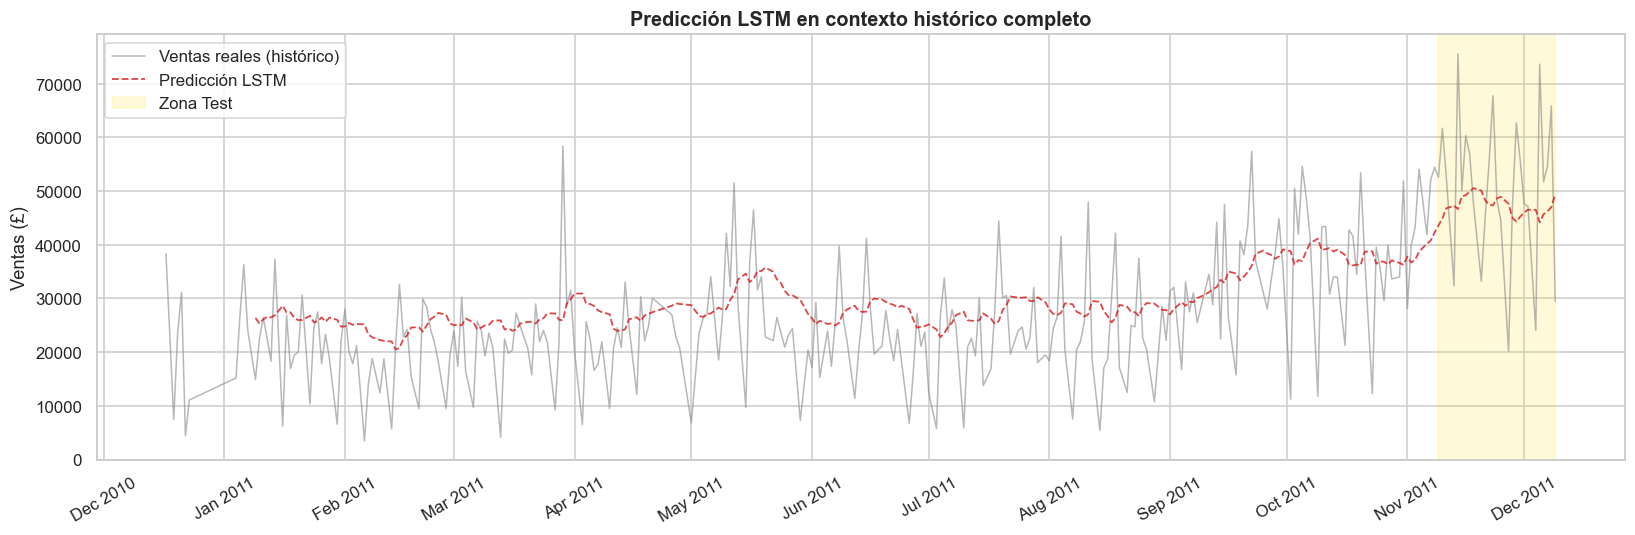

In [52]:
# Predicciones también sobre train+val para contexto
all_scaled = scaler.transform(df_daily[['TotalSales']])
X_all, _ = crear_secuencias(all_scaled, VENTANA)
y_all_pred_scaled = model.predict(X_all)
y_all_pred_real   = scaler.inverse_transform(y_all_pred_scaled)
fechas_all        = df_daily['Date'].values[VENTANA:]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_daily['Date'], df_daily['TotalSales'],
        color='#888', linewidth=1, alpha=0.6, label='Ventas reales (histórico)')
ax.plot(fechas_all, y_all_pred_real,
        color=COLOR_PRED, linewidth=1.2, alpha=0.8, linestyle='--',
        label='Predicción LSTM')
# Resaltar zona test
ax.axvspan(pd.to_datetime('2011-11-09'), df_daily['Date'].max(),
           alpha=0.15, color='gold', label='Zona Test')
ax.set_title('Predicción LSTM en contexto histórico completo')
ax.set_ylabel('Ventas (£)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 11. Resumen visual de métricas

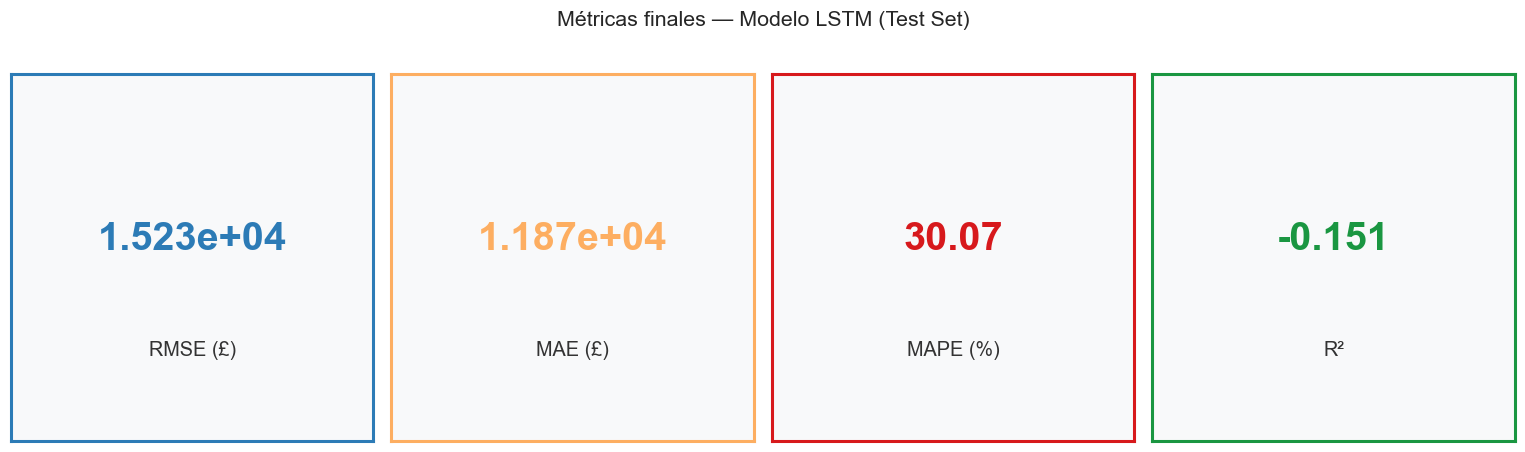

In [53]:
metricas = {'RMSE (£)': rmse, 'MAE (£)': mae, 'MAPE (%)': mape, 'R²': r2}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colores = ['#2c7bb6', '#fdae61', '#d7191c', '#1a9641']

for ax, (nombre, valor), color in zip(axes, metricas.items(), colores):
    ax.text(0.5, 0.55, f'{valor:,.4g}', ha='center', va='center',
            fontsize=26, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, nombre, ha='center', va='center',
            fontsize=13, color='#333',
            transform=ax.transAxes)
    ax.set_facecolor('#f8f9fa')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Métricas finales — Modelo LSTM (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Persistencia del modelo con Joblib
Se guarda el scaler (necesario para invertir la normalización en producción) y el modelo Keras.

In [54]:
import os, datetime

OUTPUT_DIR = 'modelo_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Guardar scaler ───────────────────────────────────────────
ruta_scaler = f'{OUTPUT_DIR}/scaler.pkl'
joblib.dump(scaler, ruta_scaler)
print(f"✅ Scaler guardado en: {ruta_scaler}")

# ── Guardar modelo Keras ─────────────────────────────────────
ruta_modelo = f'{OUTPUT_DIR}/lstm_ventas.keras'
model.save(ruta_modelo)
print(f"✅ Modelo LSTM guardado en: {ruta_modelo}")

# ── Guardar metadata del modelo ──────────────────────────────
meta = {
    'fecha_entrenamiento': str(datetime.date.today()),
    'ventana_dias': VENTANA,
    'train_end': TRAIN_END,
    'val_end': VAL_END,
    'rmse_test': round(float(rmse), 2),
    'mae_test':  round(float(mae), 2),
    'mape_test': round(float(mape), 4),
    'r2_test':   round(float(r2), 4),
    'mejor_epoca': mejor_epoca,
}
joblib.dump(meta, f'{OUTPUT_DIR}/metadata.pkl')
print(f"✅ Metadata guardada:")
for k, v in meta.items():
    print(f"   {k}: {v}")

✅ Scaler guardado en: modelo_final/scaler.pkl
✅ Modelo LSTM guardado en: modelo_final/lstm_ventas.keras
✅ Metadata guardada:
   fecha_entrenamiento: 2026-04-19
   ventana_dias: 10
   train_end: 2011-10-08
   val_end: 2011-11-08
   rmse_test: 15234.11
   mae_test: 11873.23
   mape_test: 30.0707
   r2_test: -0.151
   mejor_epoca: 2


### 12.1 Verificación: cargar el modelo y predecir

In [55]:
from tensorflow.keras.models import load_model

scaler_cargado = joblib.load(f'{OUTPUT_DIR}/scaler.pkl')
modelo_cargado = load_model(f'{OUTPUT_DIR}/lstm_ventas.keras')
meta_cargada   = joblib.load(f'{OUTPUT_DIR}/metadata.pkl')

print("✅ Modelo y scaler cargados correctamente")
print(f"   Ventana usada: {meta_cargada['ventana_dias']} días")
print(f"   RMSE reportado: £{meta_cargada['rmse_test']:,}")

# Predicción de prueba con los mismos datos de test
y_check_scaled = modelo_cargado.predict(X_test)
y_check_real   = scaler_cargado.inverse_transform(y_check_scaled)
rmse_check = np.sqrt(mean_squared_error(y_test_real, y_check_real))
print(f"   RMSE verificado:  £{rmse_check:,.2f}  ✅")

✅ Modelo y scaler cargados correctamente
   Ventana usada: 10 días
   RMSE reportado: £15,234.11
1/1 [==============================] - 0s 490ms/step
   RMSE verificado:  £15,234.11  ✅
